In [1]:
import numpy as np
from fontTools.misc.cython import returns
from tornado.testing import get_async_test_timeout


class SimpleNeuralNetwork:
    def __init__(self, W_h, b_h, W_o, b_o):
        # Weights and biases for hidden and output layers
        self.W_h = W_h
        self.b_h = b_h
        self.W_o = W_o
        self.b_o = b_o

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward_pass(self, x):
        # Hidden layer
        z_h = np.dot(self.W_h, x) + self.b_h
        h = self.sigmoid(z_h)

        # Output layer
        z_o = np.dot(self.W_o, h) + self.b_o
        o = self.sigmoid(z_o)

        return o

# Example Usage
# Input vector
x = np.array([0.5, 0.8])
# Weights and biases initialized
W_h = np.array([[0.1, 0.2], [0.3, 0.4]])
b_h = np.array([0.5, 0.6])
W_o = np.array([0.7, 0.8])
b_o = np.array([0.9])

# Create an instance and perform a forward pass
nn = SimpleNeuralNetwork(W_h, b_h, W_o, b_o)
prediction = nn.forward_pass(x)
print(f"The network's prediction is: {prediction}")

The network's prediction is: [0.87706856]


In [17]:
# OR Gate
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


def get_OR_data():
    # Input data
    X = [
        np.array([0, 0]),
        np.array([0, 1]),
        np.array([1, 0]),
        np.array([1, 1])
    ]
    # Target outputs (using simple scalars, not arrays)
    Y = [0, 1, 1, 1]
    return X, Y

# Activation function (Heaviside step function)
def unitStep(v):
    if v >= 0:
        return 1
    else:
        return 0

# --- 1. Initialization ---
X, Y = get_OR_data()

# Use floating-point numbers for weights for gradual updates
# Initialize as a SINGLE array
weights = np.array([0.1, 0.1])
bias = -0.5
eta = 0.5  # Learning rate
epochs = 10 # Max number of times to loop through the data

print(f"Initial weights: {weights}, Initial bias: {bias}\n")

# --- 2. Training Loop ---
for epoch in range(epochs):
    errors_found = 0
    print(f"--- Epoch {epoch+1} ---")

    # Loop through all 4 data points
    for i in range(len(X)):
        # --- 3. Calculate Prediction ---
        # v = (w1*x1 + w2*x2) + bias
        v = np.dot(weights, X[i]) + bias
        y = unitStep(v)

        # --- 4. Check for Error ---
        if y != Y[i]:
            errors_found += 1
            # Calculate the scalar error (target - prediction)
            error = Y[i] - y

            # --- 5. Apply Update Rule ---
            # w = w + eta * error * x
            weights = weights + eta * error * X[i]
            # b = b + eta * error
            bias = bias + eta * error

            print(f"  Input: {X[i]}, Target: {Y[i]}, Pred: {y} -> MISTAKE")
            print(f"  New weights: {weights}, New bias: {bias}")
        else:
            print(f"  Input: {X[i]}, Target: {Y[i]}, Pred: {y} -> Correct")

    # --- 6. Check for Convergence ---
    if errors_found == 0:
        print(f"\nConvergence reached at epoch {epoch+1}!")
        break
    print("-" * 20)

print(f"\nFinal trained weights: {weights}")
print(f"Final trained bias: {bias}")

Initial weights: [0.1 0.1], Initial bias: -0.5

--- Epoch 1 ---
  Input: [0 0], Target: 0, Pred: 0 -> Correct
  Input: [0 1], Target: 1, Pred: 0 -> MISTAKE
  New weights: [0.1 0.6], New bias: 0.0
  Input: [1 0], Target: 1, Pred: 1 -> Correct
  Input: [1 1], Target: 1, Pred: 1 -> Correct
--------------------
--- Epoch 2 ---
  Input: [0 0], Target: 0, Pred: 1 -> MISTAKE
  New weights: [0.1 0.6], New bias: -0.5
  Input: [0 1], Target: 1, Pred: 1 -> Correct
  Input: [1 0], Target: 1, Pred: 0 -> MISTAKE
  New weights: [0.6 0.6], New bias: 0.0
  Input: [1 1], Target: 1, Pred: 1 -> Correct
--------------------
--- Epoch 3 ---
  Input: [0 0], Target: 0, Pred: 1 -> MISTAKE
  New weights: [0.6 0.6], New bias: -0.5
  Input: [0 1], Target: 1, Pred: 1 -> Correct
  Input: [1 0], Target: 1, Pred: 1 -> Correct
  Input: [1 1], Target: 1, Pred: 1 -> Correct
--------------------
--- Epoch 4 ---
  Input: [0 0], Target: 0, Pred: 0 -> Correct
  Input: [0 1], Target: 1, Pred: 1 -> Correct
  Input: [1 0], Tar

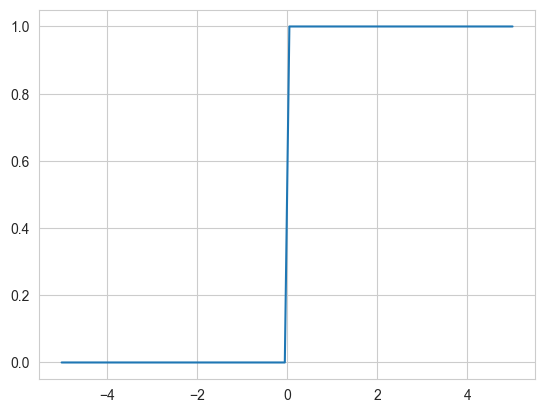

In [24]:
# Activation function

# Unit

import matplotlib.pyplot as plt
import numpy as np

def unitFunction(x):
    return np.where(x >= 0, 1, 0)

x = np.linspace(-5,5,100)

y = unitFunction(x)
plt.plot(x,y )

